<a href="https://colab.research.google.com/github/sk6952217-pixel/Underwater-Image-Enhancement_Shivam-Kumar_Grp-C2/blob/main/Final_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project on Underwater Image Enhancement

## DAY 1-10

In [ ]:
import zipfile # Import the zipfile module

zip_path = "/content/underwater_edge_enhancement_dataset.zip" # Define the path to the ZIP file
extract_path = "/content/underwater_dataset" # Define the directory where the files will be extracted

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Day 11

In [ ]:
# Resize and Normalize

from PIL import Image
import numpy as np
import os

dataset = "/content/underwater_dataset/underwater_edge_enhancement_dataset"

# Function to load, resize and normalize an image
def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((256, 256))

    img = np.array(img, dtype=np.float32)
    img = img / 255.0

    return img

# Get one sample image
input_dir = dataset + "/train/input"
target_dir = dataset + "/train/target"

input_file = sorted(os.listdir(input_dir))[0]
target_file = sorted(os.listdir(target_dir))[0]

input_path = os.path.join(input_dir, input_file)
target_path = os.path.join(target_dir, target_file)

# Load images
x = load_image(input_path)
y = load_image(target_path)

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("Input pixel range:", x.min(), "to", x.max())
print("Target pixel range:", y.min(), "to", y.max())

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)
Input pixel range: 0.0 to 0.9607843
Target pixel range: 0.0 to 1.0


In [ ]:
# Create Dataset Loader

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np


class UnderwaterDataset(Dataset):

    def __init__(self, folder):

        self.input_folder = folder + "/input"
        self.target_folder = folder + "/target"

        # Get only image files
        self.files = sorted([
            f for f in os.listdir(self.input_folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):

        name = self.files[index]

        input_img = Image.open(
            self.input_folder + "/" + name
        ).convert("RGB")

        target_img = Image.open(
            self.target_folder + "/" + name
        ).convert("RGB")

        input_img = np.array(input_img, dtype=np.float32) / 255.0
        target_img = np.array(target_img, dtype=np.float32) / 255.0

        input_img = torch.tensor(input_img).permute(2, 0, 1)
        target_img = torch.tensor(target_img).permute(2, 0, 1)

        return input_img, target_img


# New teacher-provided dataset paths
base_path = "/content/underwater_dataset/underwater_edge_enhancement_dataset"

train_data = UnderwaterDataset(
    base_path + "/train"
)

val_data = UnderwaterDataset(
    base_path + "/validation"
)

test_data = UnderwaterDataset(
    base_path + "/test"
)


print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))


# Create DataLoaders

train_loader = DataLoader(
    train_data,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=8,
    shuffle=False
)


# Check one training batch

x, y = next(iter(train_loader))

print("Input batch shape:", x.shape)
print("Target batch shape:", y.shape)

Train: 107
Validation: 23
Test: 23
Input batch shape: torch.Size([8, 3, 256, 256])
Target batch shape: torch.Size([8, 3, 256, 256])


In [ ]:
# Create Dataset Configuration
import json
import os

config = {
    "version": "Teacher_Dataset",
    "image_size": [256, 256],
    "image_format": "PNG",
    "channels": 3,
    "normalization": "0-1",
    "train_pairs": 107,
    "validation_pairs": 23,
    "test_pairs": 23,
    "total_pairs": 153,
    "batch_size": 8,
    "augmentation": "None",
    "split": {
        "train": "70%",
        "validation": "15%",
        "test": "15%"
    },
    "seed": 20260922
}

config_path = "/content/underwater_dataset/underwater_edge_enhancement_dataset/preprocessing_config.json"

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Dataset configuration saved!")

Dataset configuration saved!


# DAY 13

In [ ]:
# 4 classical methods
import cv2
import numpy as np
import os
from PIL import Image

input_dir = dataset + "/train/input"
target_dir = dataset + "/train/target"

# Create output folders to store the results of each classical method.
os.makedirs("/content/classical_results/histogram_equalization", exist_ok=True)
os.makedirs("/content/classical_results/clahe", exist_ok=True)
os.makedirs("/content/classical_results/gamma", exist_ok=True)
os.makedirs("/content/classical_results/white_balance", exist_ok=True)


# Histogram Equalization
def apply_histogram_equalization(img):
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb) # Convert RGB to YCrCb
    y, cr, cb = cv2.split(ycrcb) # Separate luminance channel
    y = cv2.equalizeHist(y) # Apply Histogram Equalization
    result = cv2.merge((y, cr, cb))   # Merge channels
    return cv2.cvtColor(result, cv2.COLOR_YCrCb2RGB)  # Convert back to RGB


# CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe(img):
    # Convert the image from RGB to LAB color space (L=lightness, A=green-red, B=blue-yellow).
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    # Split the LAB image into its individual L, A, and B channels.
    l, a, b = cv2.split(lab)

    # Create a CLAHE object with a clip limit of 2.0 and a tile grid size of 8x8.
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    # Apply CLAHE to the L (lightness) channel to enhance contrast.
    l = clahe.apply(l)

    # Merge the enhanced L channel back with the original A and B channels.
    # Convert the LAB image back to RGB color space and return it.
    return cv2.cvtColor(
        cv2.merge((l, a, b)),
        cv2.COLOR_LAB2RGB
    )


# Gamma Correction
def apply_gamma(img, gamma=1.2):
    # Create a lookup table (LUT) for gamma correction.
    # Each pixel value (0-255) is adjusted based on the gamma value.
    table = np.array([
        ((i / 255.0) ** (1 / gamma)) * 255  # Calculate the new pixel value using the gamma formula.
        for i in np.arange(256)  # Iterate through all possible pixel values (0 to 255).
    ]).astype("uint8")  # Ensure the LUT contains 8-bit unsigned integers.

    # Apply the gamma correction using the lookup table to the image.
    return cv2.LUT(img, table)


# White Balance
def apply_white_balance(img):
    # Convert the image from RGB to LAB color space.
    result = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Calculate the average values for the 'a' (green-red) and 'b' (blue-yellow) channels.
    avg_a = np.mean(result[:, :, 1])
    avg_b = np.mean(result[:, :, 2])

    # Adjust the 'a' channel based on its average and the lightness (L) channel.
    result[:, :, 1] = result[:, :, 1] - (
        (avg_a - 128) * (result[:, :, 0] / 255.0) * 1.1
    )

    # Adjust the 'b' channel based on its average and the lightness (L) channel.
    result[:, :, 2] = result[:, :, 2] - (
        (avg_b - 128) * (result[:, :, 0] / 255.0) * 1.1
    )

    # Convert the balanced LAB image back to RGB color space and return it.
    return cv2.cvtColor(result, cv2.COLOR_LAB2RGB)


# Apply methods to all images in the input directory.
for file in os.listdir(input_dir):

    # Skip files that are not PNG images.
    if not file.endswith(".png"):
        continue

    # Construct the full path to the current input image.
    path = os.path.join(input_dir, file)

    # Open the image using Pillow, convert to RGB, and then to a NumPy array.
    img = np.array(Image.open(path).convert("RGB"))

    result = apply_histogram_equalization(img)

    clahe = apply_clahe(img)

    gamma = apply_gamma(img)

    wb = apply_white_balance(img)

    # Save the processed image to its respective output folder.
    Image.fromarray(result).save(
        "/content/classical_results/histogram_equalization/" + file
    )

    Image.fromarray(clahe).save(
        "/content/classical_results/clahe/" + file
    )

    Image.fromarray(gamma).save(
        "/content/classical_results/gamma/" + file
    )

    Image.fromarray(wb).save(
        "/content/classical_results/white_balance/" + file
    )

print("Classical enhancement completed!")

Classical enhancement completed!


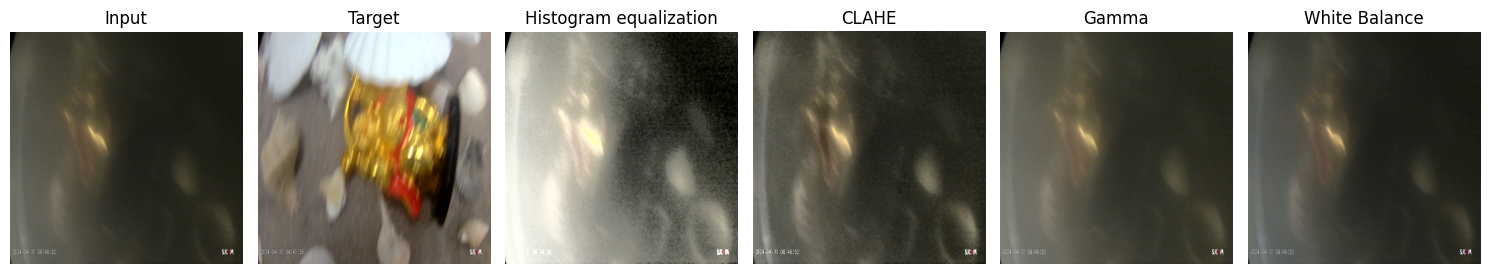

In [ ]:
# Visual comparison
import matplotlib.pyplot as plt
from PIL import Image

file = os.listdir(input_dir)[0]

input_img = Image.open(input_dir + "/" + file)
target_img = Image.open(target_dir + "/" + file)
he_img = Image.open("/content/classical_results/histogram_equalization/" + file)
clahe_img = Image.open("/content/classical_results/clahe/" + file)
gamma_img = Image.open("/content/classical_results/gamma/" + file)
wb_img = Image.open("/content/classical_results/white_balance/" + file)

images = [
    input_img,
    target_img,
    he_img,
    clahe_img,
    gamma_img,
    wb_img
]

titles = [
    "Input",
    "Target",
    "Histogram equalization",
    "CLAHE",
    "Gamma",
    "White Balance"
]

plt.figure(figsize=(15, 4))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# calculate PSNR + SSIM
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity  # Import PSNR and SSIM metrics from scikit-image.

input_dir = dataset + "/train/input"
target_dir = dataset + "/train/target"

methods = {  # Dictionary mapping method names to their respective output folders.
    "Histogram Equalization":"/content/classical_results/histogram_equalization",
    "CLAHE": "/content/classical_results/clahe",
    "Gamma": "/content/classical_results/gamma",
    "White Balance": "/content/classical_results/white_balance"
}

results = {}  # Initialize an empty dictionary to store the PSNR and SSIM scores for each method.

for method, folder in methods.items():  # Loop through each classical enhancement method.
    psnr_values = []  # Initialize a list to store PSNR values for the current method.
    ssim_values = []  # Initialize a list to store SSIM values for the current method.

    for file in os.listdir(input_dir):  # Loop through each image file in the input directory.
        if not file.endswith(".png"):  # Skip files that are not PNG images.
            continue

        target_path = os.path.join(target_dir, file)  # path to the corresponding target image.
        result_path = os.path.join(folder, file)  # path to the processed image by the current method.

        if not os.path.exists(target_path) or not os.path.exists(result_path):  # Skip if either target or result image is missing.
            continue

        target = cv2.imread(target_path)  # Read the target image using OpenCV.
        result = cv2.imread(result_path)  # Read the processed image using OpenCV.

        target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)  # Convert target image from BGR (OpenCV default) to RGB.
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)  # Convert result image from BGR to RGB.

        # Calculate Peak Signal-to-Noise Ratio (PSNR) between the target and result images.
        # data_range=255 indicates that pixel values are in the 0-255 range.
        psnr = peak_signal_noise_ratio(target, result, data_range=255)

        # Calculate Structural Similarity Index (SSIM) between the target and result images.
        # channel_axis=2 specifies that color channels are the last dimension (RGB).
        ssim = structural_similarity(
            target,
            result,
            channel_axis=2,
            data_range=255
        )

        psnr_values.append(psnr)
        ssim_values.append(ssim)

    # Store the average PSNR and SSIM for the current method in the 'results' dictionary.
    results[method] = {
        "PSNR": np.mean(psnr_values),
        "SSIM": np.mean(ssim_values)
    }

print("Classical Baseline Results")

for method, scores in results.items():  # Iterate through the calculated scores for each method.
    # Print the method name and its average PSNR and SSIM scores, formatted to two and four decimal places respectively.
    print(f"{method}: "f"PSNR = {scores['PSNR']:.2f}, "f"SSIM = {scores['SSIM']:.4f}")

Classical Baseline Results
Histogram Equalization: PSNR = 8.06, SSIM = 0.2478
CLAHE: PSNR = 8.43, SSIM = 0.2689
Gamma: PSNR = 8.47, SSIM = 0.3194
White Balance: PSNR = 7.79, SSIM = 0.2774


In [ ]:
# Edge extraction + edge similarity
import os
import cv2
import numpy as np

input_dir = dataset + "/train/input"
target_dir = dataset + "/train/target"

methods = {  # Dictionary mapping method names to their respective output folders.
    "Histogram Equalization":"/content/classical_results/histogram_equalization",
    "CLAHE": "/content/classical_results/clahe",
    "Gamma": "/content/classical_results/gamma",
    "White Balance": "/content/classical_results/white_balance"
}

def edge_f1(result, target):  # Define a function to calculate the F1-score for edge similarity.
    # Convert both the result and target images to grayscale for edge detection.
    result_gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    target_gray = cv2.cvtColor(target, cv2.COLOR_RGB2GRAY)

    # Apply Canny edge detection to both grayscale images. Thresholds (100, 200) determine strong and weak edges.
    # The '> 0' converts the edge image to a boolean array where True indicates an edge pixel.
    result_edges = cv2.Canny(result_gray, 100, 200) > 0
    target_edges = cv2.Canny(target_gray, 100, 200) > 0

    # Calculate the number of true positives.
    true_positive = np.logical_and(result_edges, target_edges).sum()

    # Calculate Precision: (True Positives) / (True Positives + False Positives).
    # 1e-8 is added to avoid division by zero if no edges are detected.
    precision = true_positive / (result_edges.sum() + 1e-8)
    # Calculate Recall: (True Positives) / (True Positives + False Negatives).
    recall = true_positive / (target_edges.sum() + 1e-8)

    # Calculate the F1-score, which is the harmonic mean of precision and recall.
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return f1

results = {}

for method, folder in methods.items():  # Loop through each classical enhancement method.

    edge_scores = []  # Initialize a list to store edge F1-scores for the current method.

    for file in os.listdir(input_dir):  # Loop through each image file in the input directory.

        if not file.endswith(".png"):  # Skip files that are not PNG images.
            continue

        target_path = os.path.join(target_dir, file)  # path to the corresponding target image.
        result_path = os.path.join(folder, file)  # path to the processed image by the current method.

        if not os.path.exists(target_path) or not os.path.exists(result_path):  # Skip if either target or result image is missing.
            continue

        target = cv2.imread(target_path)  # Read the target image using OpenCV.
        result = cv2.imread(result_path)  # Read the processed image using OpenCV.

        target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)  # Convert target image from BGR (OpenCV default) to RGB.
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)  # Convert result image from BGR to RGB.

        score = edge_f1(result, target)  # Calculate the edge F1-score using the defined function.
        edge_scores.append(score)

    # Store the average edge F1-score for the current method in the 'results' dictionary.
    results[method] = np.mean(edge_scores)

print("Edge Preservation Results")

for method, score in results.items():  # Iterate through the calculated scores for each method.

    print(f"{method}: Edge F1 = {score:.4f}")

Edge Preservation Results
Histogram Equalization: Edge F1 = 0.0517
CLAHE: Edge F1 = 0.0788
Gamma: Edge F1 = 0.0754
White Balance: Edge F1 = 0.0737


# Day 16

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
base_path = "/content/underwater_dataset/underwater_edge_enhancement_dataset" # Define the base directory where the processed dataset is stored

train_input = base_path + "/train/input"
train_target = base_path + "/train/target"

val_input = base_path + "/validation/input"
val_target = base_path + "/validation/target"

test_input = base_path + "/test/input"
test_target = base_path + "/test/target"


In [ ]:
class UnderwaterDataset(Dataset):

    def __init__(self, input_dir, target_dir): # Constructor for the dataset, taking paths to input and target image directories
        self.input_dir = input_dir # Store the input directory path
        self.target_dir = target_dir

        self.files = sorted(os.listdir(input_dir)) # Get a sorted list of all filenames in the input directory

        self.transform = transforms.ToTensor() # Initialize a transformation to convert PIL images to PyTorch tensors

    def __len__(self): # Method to return the total number of items in the dataset
        return len(self.files)

    def __getitem__(self, idx): # Method to retrieve an item (input and target image pair) at a given index

        filename = self.files[idx] # Get the filename for the current index

        input_img = Image.open( os.path.join(self.input_dir, filename) # Construct the full path to the input image
        ).convert("RGB") # Convert the input image to RGB format

        target_img = Image.open(os.path.join(self.target_dir, filename) # Construct the full path to the target image
        ).convert("RGB") # Convert the target image to RGB format

        input_img = self.transform(input_img) # Apply the ToTensor transformation to the input image
        target_img = self.transform(target_img)

        return input_img, target_img # Return the transformed input and target image tensors

In [ ]:
train_dataset = UnderwaterDataset( # Create an instance of the UnderwaterDataset for the training data
    train_input, # Path to the input images for the training set
    train_target
)

val_dataset = UnderwaterDataset( # Create an instance of the UnderwaterDataset for the validation data
    val_input, # Path to the input images for the validation set
    val_target
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 107
Validation images: 23


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if a CUDA-enabled GPU is available; if so, use it, otherwise use the CPU.

print("Device:", device)

Device: cuda


In [ ]:
class CNN(nn.Module): # Define a class named CNN

    def __init__(self): # Constructor method for the CNN class
        super(CNN, self).__init__() # Call the constructor of the parent class (nn.Module)

        self.network = nn.Sequential( # Define a sequential container for the layers of the neural network

            # First Convolutional Block
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Convolutional layer: 3 input channels (RGB), 32 output channels, 3x3 kernel, padding=1 to maintain spatial dimensions
            nn.ReLU(), # ReLU activation function to introduce non-linearity

            # Second Convolutional Block
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # Another convolutional layer: 32 input channels, 32 output channels, 3x3 kernel, padding=1
            nn.ReLU(), # ReLU activation function

            # Output Convolutional Layer
            nn.Conv2d(32, 3, kernel_size=3, padding=1), # Output convolutional layer: 32 input channels, 3 output channels (for RGB image output), 3x3 kernel, padding=1
            nn.Sigmoid() # Sigmoid activation function to scale output pixel values between 0 and 1
        )

    def forward(self, x): # Defines the forward pass
        return self.network(x) # Pass the input 'x' through the defined sequential network


model = CNN().to(device) # Create an instance of the CNN model and move it to the specified device (GPU or CPU)

print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [ ]:
criterion = nn.MSELoss() # Define the loss function as Mean Squared Error (MSE)

optimizer = torch.optim.Adam( # Initialize the Adam optimizer.
    model.parameters(), # Tell the optimizer to adjust the parameters (weights and biases) of the 'model'.
    lr=0.001 # Set the learning rate to 0.001
)

In [ ]:
epochs = 200 # Set the total number of training epochs

train_losses = []
val_losses = []

for epoch in range(epochs): # Loop through each epoch

    # Training phase
    model.train() # Set the model to training mode

    total_train_loss = 0 # Initialize total training loss for the current epoch

    for inputs, targets in train_loader: # Iterate over batches of training data

        inputs = inputs.to(device) # Move input images to the specified device
        targets = targets.to(device)

        optimizer.zero_grad() # Reset gradients from the previous iteration

        outputs = model(inputs) # Perform a forward pass to get model predictions

        loss = criterion(outputs, targets) # Calculate the loss between predictions and targets

        loss.backward() # Perform backpropagation to calculate gradients

        optimizer.step() # Update model parameters using the optimizer

        total_train_loss += loss.item() # Accumulate the loss for the current batch

    train_loss = total_train_loss / len(train_loader) # Calculate the average training loss for the epoch


    # Validation phase
    model.eval() # Set the model to evaluation mode

    total_val_loss = 0 # Initialize total validation loss for the current epoch

    with torch.no_grad(): # Disable gradient calculation during validation to save memory and speed up

        for inputs, targets in val_loader: # Iterate over batches of validation data

            inputs = inputs.to(device) # Move input images to the specified device
            targets = targets.to(device)

            outputs = model(inputs) # Perform a forward pass to get model predictions

            loss = criterion(outputs, targets) # Calculate the loss between predictions and targets

            total_val_loss += loss.item() # Accumulate the loss for the current batch

    val_loss = total_val_loss / len(val_loader) # Calculate the average validation loss for the epoch


    train_losses.append(train_loss) # Store the training loss for the current epoch
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )

Epoch 1/200 - Train Loss: 0.0470 - Val Loss: 0.0471
Epoch 2/200 - Train Loss: 0.0457 - Val Loss: 0.0466
Epoch 3/200 - Train Loss: 0.0458 - Val Loss: 0.0464
Epoch 4/200 - Train Loss: 0.0456 - Val Loss: 0.0460
Epoch 5/200 - Train Loss: 0.0451 - Val Loss: 0.0460
Epoch 6/200 - Train Loss: 0.0459 - Val Loss: 0.0463
Epoch 7/200 - Train Loss: 0.0454 - Val Loss: 0.0458
Epoch 8/200 - Train Loss: 0.0457 - Val Loss: 0.0459
Epoch 9/200 - Train Loss: 0.0451 - Val Loss: 0.0459
Epoch 10/200 - Train Loss: 0.0455 - Val Loss: 0.0458
Epoch 11/200 - Train Loss: 0.0444 - Val Loss: 0.0457
Epoch 12/200 - Train Loss: 0.0447 - Val Loss: 0.0458
Epoch 13/200 - Train Loss: 0.0450 - Val Loss: 0.0456
Epoch 14/200 - Train Loss: 0.0452 - Val Loss: 0.0456
Epoch 15/200 - Train Loss: 0.0450 - Val Loss: 0.0455
Epoch 16/200 - Train Loss: 0.0448 - Val Loss: 0.0455
Epoch 17/200 - Train Loss: 0.0447 - Val Loss: 0.0455
Epoch 18/200 - Train Loss: 0.0447 - Val Loss: 0.0455
Epoch 19/200 - Train Loss: 0.0450 - Val Loss: 0.0455
Ep

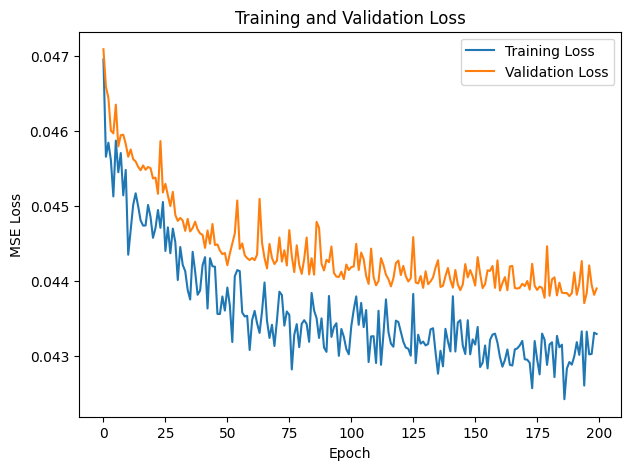

In [ ]:
plt.figure(figsize=(7,5)) # width=7, height=5 inches

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend() # Display the legend, which uses the labels defined in plt.plot()
plt.show()

In [ ]:
model.eval() # Set the model to evaluation mode.

inputs, targets = next(iter(val_loader)) # Get a batch of input and target images from the validation data loader.

inputs = inputs.to(device) # Move the input images to the specified device

with torch.no_grad(): # Disable gradient calculation for this block.
    outputs = model(inputs) # Pass the input images through the model to get the enhanced (output) images.

inputs = inputs.cpu() # Move the input images back to the CPU for visualization with matplotlib.
outputs = outputs.cpu() # Move the output images back to the CPU for visualization with matplotlib.

In [ ]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.filters import sobel

model.eval()

psnr_scores = []
ssim_scores = []
edge_scores = []

edge_target_dir = base_path + "/test/edge_target"

with torch.no_grad():

    for batch_idx, (inputs, targets) in enumerate(test_loader):

        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)

        outputs = outputs.clamp(0, 1)

        # Batch images
        for i, (pred, target) in enumerate(zip(outputs, targets)):

            pred_np = pred.cpu().numpy().transpose(1, 2, 0)
            target_np = target.cpu().numpy().transpose(1, 2, 0)

            # PSNR
            psnr = peak_signal_noise_ratio(
                target_np, pred_np, data_range=1.0
            )

            # SSIM
            ssim = structural_similarity(
                target_np,
                pred_np,
                channel_axis=2,
                data_range=1.0
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

print("CNN PSNR    :", round(np.mean(psnr_scores), 4))
print("CNN SSIM    :", round(np.mean(ssim_scores), 4))

CNN PSNR    : 13.5063
CNN SSIM    : 0.4767


In [ ]:
import os
import cv2
import numpy as np

edge_scores = []

test_files = sorted([
    f for f in os.listdir(test_input)
    if f.lower().endswith(".png")
])

with torch.no_grad():

    for filename in test_files:

        input_img = Image.open(
            os.path.join(test_input, filename)
        ).convert("RGB")

        input_tensor = transforms.ToTensor()(input_img).unsqueeze(0).to(device)

        output = model(input_tensor)
        output = output.squeeze(0).cpu().numpy().transpose(1, 2, 0)

        # CNN output → grayscale → edge
        output_gray = np.mean(output, axis=2)
        output_edge = sobel(output_gray)
        output_edge = output_edge > 0.1

        #  edge target
        edge_path = os.path.join(edge_target_dir, filename)

        edge_target = cv2.imread(
            edge_path,
            cv2.IMREAD_GRAYSCALE
        )

        edge_target = edge_target > 0

        # Edge F1
        tp = np.logical_and(output_edge, edge_target).sum()
        fp = np.logical_and(output_edge, ~edge_target).sum()
        fn = np.logical_and(~output_edge, edge_target).sum()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)

        edge_f1 = 2 * precision * recall / (
            precision + recall + 1e-8
        )

        edge_scores.append(edge_f1)

print("CNN Test Edge F1 :", round(np.mean(edge_scores), 4))

CNN Test Edge F1 : 0.0527


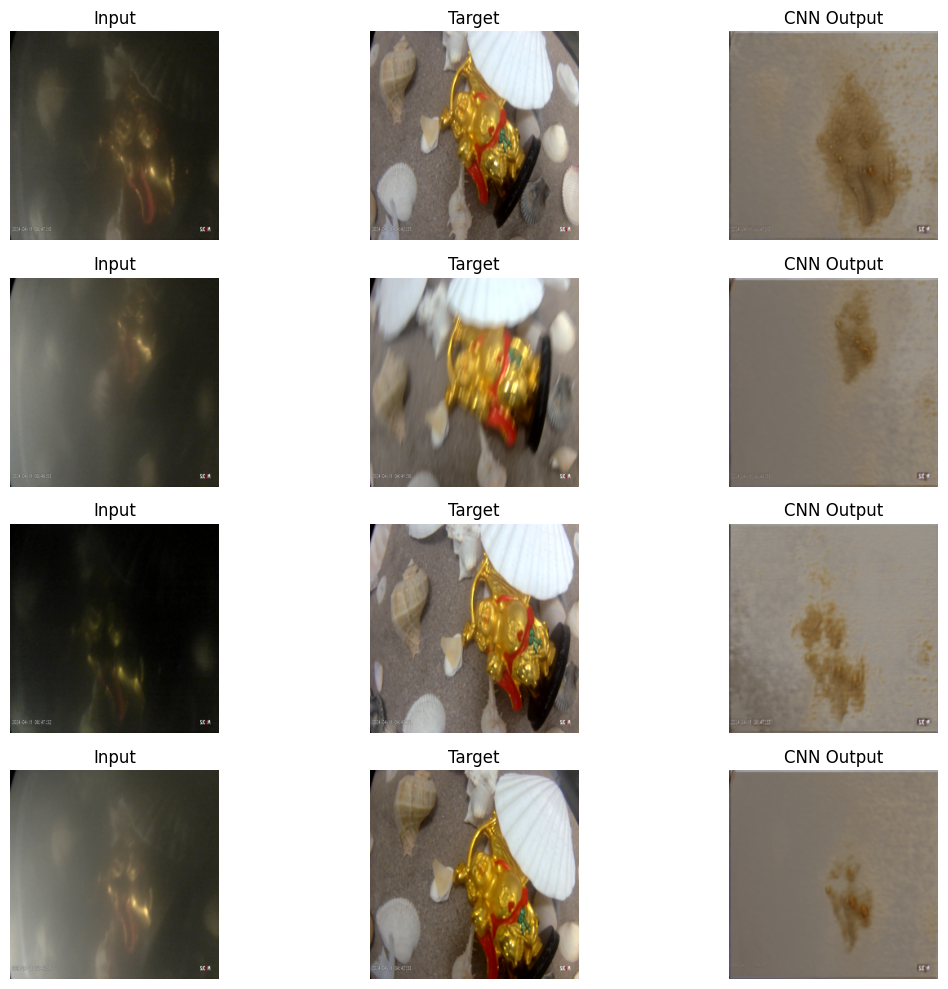

In [ ]:
import matplotlib.pyplot as plt

model.eval()

inputs, targets = next(iter(test_loader))

inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    outputs = model(inputs)

outputs = outputs.clamp(0, 1)

num_display = min(len(inputs), 4)

plt.figure(figsize=(12, 10))

for i in range(num_display):

    plt.subplot(num_display, 3, i * 3 + 1)
    plt.imshow(inputs[i].cpu().permute(1, 2, 0))
    plt.title("Input")
    plt.axis("off")

    plt.subplot(num_display, 3, i * 3 + 2)
    plt.imshow(targets[i].cpu().permute(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

    plt.subplot(num_display, 3, i * 3 + 3)
    plt.imshow(outputs[i].cpu().permute(1, 2, 0))
    plt.title("CNN Output")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Day 17

In [ ]:
import cv2
import numpy as np
import os
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

input_dir = base_path + "/validation/input"
target_dir = base_path + "/validation/target"

# Gamma refinement
candidates = {
    "Gamma_1": 0.8,
    "Gamma_2": 1.0,
    "Gamma_3": 1.2,
    "Gamma_4": 1.5
}

In [ ]:
# Apply gamma and calculate PSNR + SSIM
results = {} # Initialize an empty dictionary to store the evaluation results for each Gamma candidate

for name, gamma in candidates.items(): # Iterate through each gamma candidate and its parameters

    psnr_scores = [] # Initialize a list to store PSNR scores for the current Gamma candidate
    ssim_scores = []

    for file in os.listdir(input_dir): # Iterate through each image file in the input directory

        if not file.endswith(".png"): # Skip files that are not PNG images
            continue

        inp = np.array(Image.open(os.path.join(input_dir, file) # Construct the full path to the input image
        ).convert("RGB")) # Convert the input image to RGB format and then to a NumPy array

        target = np.array(Image.open(os.path.join(target_dir, file) # Construct the full path to the target image
        ).convert("RGB")) # Convert the target image to RGB format and then to a NumPy array

       # Gamma correction
        table = np.array(
            [((i / 255.0) ** (1.0 / gamma)) * 255 for i in range(256)]
        ).astype("uint8")
        output = cv2.LUT(inp, table)

        psnr_scores.append(peak_signal_noise_ratio( # Function to compute PSNR
                target, output, data_range=255 # Compare target and output images
            ))

        ssim_scores.append( # Calculate and store the SSIM score
            structural_similarity( # Function to compute SSIM
                target,
                output,
                channel_axis=2, # Specify that the color channels are along the third axis (index 2)
                data_range=255
            ))

    results[name] = [ # Store the mean PSNR and SSIM scores for the current Gamma candidate
        np.mean(psnr_scores),
        np.mean(ssim_scores)
    ]

for name, scores in results.items(): # Iterate through the calculated results for each Gamma candidate
    print(name,"PSNR =", round(scores[0], 4),"SSIM =", round(scores[1], 4))

Gamma_1 PSNR = 6.9401 SSIM = 0.2126
Gamma_2 PSNR = 7.7274 SSIM = 0.2768
Gamma_3 PSNR = 8.4427 SSIM = 0.3189
Gamma_4 PSNR = 9.4528 SSIM = 0.3626


In [ ]:
def edge_f1(result, target):

    result_gray = cv2.cvtColor( # Convert the result image to grayscale
        result, cv2.COLOR_RGB2GRAY)

    target_gray = cv2.cvtColor( # Convert the target image to grayscale
        target, cv2.COLOR_RGB2GRAY)

    result_edges = cv2.Canny( # Apply Canny edge detection to the result image
        result_gray, 100, 200) > 0 # Edge detection with hysteresis thresholds

    target_edges = cv2.Canny( # Apply Canny edge detection to the target image
        target_gray, 100, 200) > 0 # Edge detection with hysteresis thresholds

    tp = np.logical_and( result_edges,target_edges).sum() # Calculate the number of true positives


    precision = tp / (result_edges.sum() + 1e-8) # Calculate precision
    recall = tp / (target_edges.sum() + 1e-8) # Calculate recall

    return 2 * precision * recall / ( precision + recall + 1e-8) # Calculate the F1-score


for name, gamma in candidates.items(): # Iterate through each Gamma candidate and its parameters

    scores = [] # Initialize a list to store edge F1 scores for the current candidate

    for file in os.listdir(input_dir): # Iterate through each image file in the input directory

        if not file.endswith(".png"): # Skip non-PNG files
            continue

        inp = np.array(Image.open( # Open and convert input image to RGB NumPy array
            os.path.join(input_dir, file)
        ).convert("RGB"))

        target = np.array(Image.open( # Open and convert target image to RGB NumPy array
            os.path.join(target_dir, file)
        ).convert("RGB"))

        # Gamma correction
        table = np.array([
            ((i / 255.0) ** (1.0 / gamma)) * 255
            for i in range(256)
        ]).astype("uint8")

        output = cv2.LUT(inp, table)

        scores.append(edge_f1(output, target)) # Calculate and append the edge F1 score

    results[name].append(np.mean(scores))

print("\nGamma Refinement Results")

for name, scores in results.items(): # Iterate through the results for each Gamma candidate
    print(name,"PSNR =", round(scores[0], 4),"SSIM =", round(scores[1], 4),"Edge F1 =", round(scores[2], 4))


Gamma Refinement Results
Gamma_1 PSNR = 6.9401 SSIM = 0.2126 Edge F1 = 0.0697
Gamma_2 PSNR = 7.7274 SSIM = 0.2768 Edge F1 = 0.0718
Gamma_3 PSNR = 8.4427 SSIM = 0.3189 Edge F1 = 0.0728
Gamma_4 PSNR = 9.4528 SSIM = 0.3626 Edge F1 = 0.0719


In [ ]:
best = max(
    results, # Iterate through the 'results' dictionary containing scores for each candidate
    key=lambda x: np.mean([ # The key for comparison is the mean of normalized scores (PSNR, SSIM, Edge F1)
        results[x][0] / max(r[0] for r in results.values()), # Normalize PSNR score by the maximum PSNR across all candidates
        results[x][1] / max(r[1] for r in results.values()),
        results[x][2] / max(r[2] for r in results.values())
    ])
)

print("Best refined method:", best)
print("PSNR:", results[best][0])
print("SSIM:", results[best][1])
print("Edge F1:", results[best][2])

Best refined method: Gamma_4
PSNR: 9.452796458969342
SSIM: 0.36261831071263256
Edge F1: 0.07188177795415965


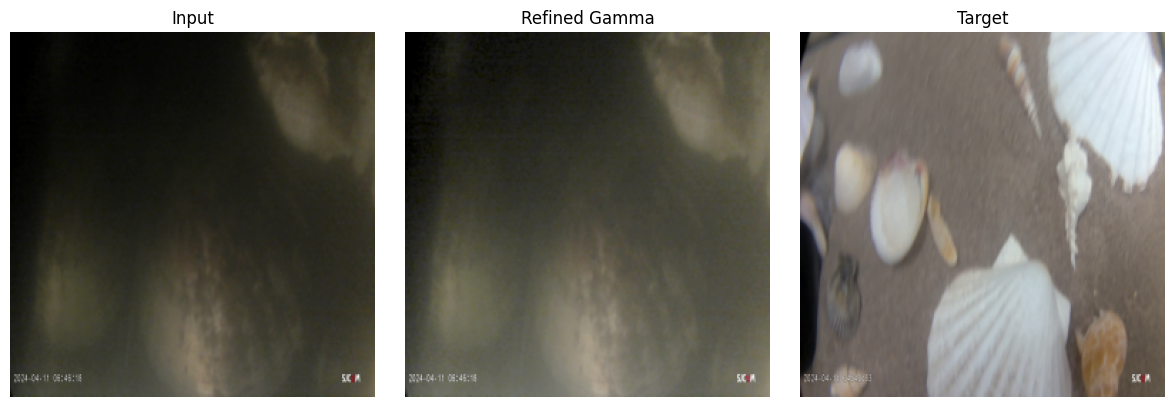

In [ ]:
best_gamma = candidates[best] # Retrieve the clip limit and grid size parameters of the best performing CLAHE method.

file = os.listdir(input_dir)[0] # Select the first file from the input directory to demonstrate the best CLAHE method.

inp = np.array(Image.open(os.path.join(input_dir, file) # Construct the full path to the input image.
).convert("RGB")) # Convert the input image to RGB format and then to a NumPy array.

target = np.array(Image.open(os.path.join(target_dir, file) # Construct the full path to the target image.
).convert("RGB")) # Convert the target image to RGB format and then to a NumPy array.

# Apply best Gamma correction
table = np.array([
    ((i / 255.0) ** (1.0 / best_gamma)) * 255
    for i in range(256)
]).astype("uint8")

output = cv2.LUT(inp, table)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(inp)
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(output)
plt.title("Refined Gamma")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(target)
plt.title("Target")
plt.axis("off")

plt.tight_layout()
plt.show()

# Day 19

In [ ]:
import pandas as pd

# Define configurations for CNN parameter experiments, specifically learning rates
configs = [
    ("CNN_LR_0001", 0.0001), # Experiment name and learning rate for the first configuration
    ("CNN_LR_001", 0.001),   # Experiment name and learning rate for the second configuration
    ("CNN_LR_01", 0.01)     # Experiment name and learning rate for the third configuration
]

cnn_log = []

for name, lr in configs: # Iterate through each configuration

    model = CNN().to(device) # Create a new instance of the CNN model and move it to the specified device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Initialize an Adam optimizer for the model with the current learning rate

    best_val_loss = float("inf")

    for epoch in range(200):

        model.train()
        for inputs, targets in train_loader: # Iterate over batches from the training data loader
            inputs, targets = inputs.to(device), targets.to(device) # Move input and target tensors to the specified device

            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, targets) # Calculate the loss
            loss.backward() # Perform backpropagation to compute gradients
            optimizer.step() # Update model parameters

        model.eval()
        val_loss = 0 # Initialize validation loss for the current epoch

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device) # Move tensors to the specified device
                output = model(inputs)
                val_loss += criterion(output, targets).item() # Accumulate validation loss

        val_loss /= len(val_loader) # Calculate the average validation loss for the epoch
        best_val_loss = min(best_val_loss, val_loss)

    cnn_log.append([name, lr, best_val_loss]) # Store the experiment results (name, learning rate, best validation loss)

cnn_log = pd.DataFrame( # Convert the collected experiment log into a pandas DataFrame
    cnn_log,
    columns=["Experiment", "Learning_Rate", "Best_Val_Loss"]
)

display(cnn_log) # Display the DataFrame containing CNN experiment results

,Experiment,Learning_Rate,Best_Val_Loss
0,CNN_LR_0001,0.0001,0.044667
1,CNN_LR_001,0.0010,0.043594
2,CNN_LR_01,0.0100,0.044056


In [ ]:
best_cnn = cnn_log.loc[cnn_log["Best_Val_Loss"].idxmin()] # Find the row in cnn_log with the minimum 'Best_Val_Loss'

print("Best CNN:")
print(best_cnn) # Display the details of the best CNN configuration

Best CNN:
Experiment       CNN_LR_001
Learning_Rate         0.001
Best_Val_Loss      0.043594
Name: 1, dtype: object


In [ ]:
# CLAHE CONTROLLED EXPERIMENTS

import cv2
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

input_dir = "/content/underwater_dataset/underwater_edge_enhancement_dataset/validation/input"
target_dir = "/content/underwater_dataset/underwater_edge_enhancement_dataset/validation/target"

gamma_values = {
    "Gamma-1": 1.3,
    "Gamma-2": 1.5,
    "Gamma-3": 1.7,
    "Gamma-4": 1.9
}

results = []

for name, gamma in gamma_values.items(): # Iterate through each CLAHE experiment

    psnr_scores = []
    ssim_scores = []

    for file in os.listdir(input_dir): # Iterate through each image file in the input directory

        input_path = os.path.join(input_dir, file) # Changed 'filename' to 'file'
        target_path = os.path.join(target_dir, file)

        if not os.path.exists(target_path): # Ensure target path exists
            continue

        img = cv2.imread(input_path)
        target = cv2.imread(target_path)

        if img is None or target is None:
            continue

        # Ensure both images have the same dimensions (e.g., resize if necessary or skip)
        # For this context, assuming images in dataset are consistent. If not, add error handling or resizing.
        if img.shape != target.shape:
            print(f"Skipping {file} due to dimension mismatch: input {img.shape}, target {target.shape}")
            continue

        inv_gamma = 1.0 / gamma
        table = np.array(
            [(i / 255.0) ** inv_gamma * 255 for i in np.arange(256)]
        ).astype("uint8")

        result = cv2.LUT(img, table)

        psnr_scores.append(peak_signal_noise_ratio(target,result,data_range=255)) # Changed 'output' to 'result'

        ssim_scores.append( # Calculate SSIM and append to list
            structural_similarity(
                target,
                result, # Changed 'output' to 'result'
                channel_axis=2,
                data_range=255
            )
        )

    # Only append if scores were collected for the current gamma value
    if psnr_scores and ssim_scores:
        results.append({ # Store the aggregated results for the current CLAHE experiment
            "Experiment": name,
            "Method": "Refined Gamma",
            "Gamma": gamma, # Added Gamma value to results
            "Validation_PSNR": np.mean(psnr_scores),
            "Validation_SSIM": np.mean(ssim_scores)
        })
    else:
        print(f"No valid images processed for {name}")

gamma_log = pd.DataFrame(results)
print(gamma_log)

  Experiment         Method  Gamma  Validation_PSNR  Validation_SSIM
0    Gamma-1  Refined Gamma    1.3         8.799911         0.336182
1    Gamma-2  Refined Gamma    1.5         9.452796         0.362618
2    Gamma-3  Refined Gamma    1.7        10.012249         0.380553
3    Gamma-4  Refined Gamma    1.9        10.466647         0.393010


In [ ]:
best_gamma = gamma_log.loc[gamma_log["Validation_PSNR"].idxmax()]

print("Best Gamma Configuration")
print("Experiment:", best_gamma["Experiment"])
print("Gamma:", best_gamma["Gamma"])
print("PSNR:", best_gamma["Validation_PSNR"])
print("SSIM:", best_gamma["Validation_SSIM"])

Best Gamma Configuration
Experiment: Gamma-4
Gamma: 1.9
PSNR: 10.466647405869809
SSIM: 0.3930100288927031


In [ ]:
# Create experiment log

cnn_log = cnn_log.copy() # Create a copy of the CNN experiment log to avoid modifying the original DataFrame

cnn_log = cnn_log.rename(columns={"Best_Val_Loss": "Validation_Loss"}) # Rename 'Best_Val_Loss' to 'Validation_Loss'

gamma_log = gamma_log.copy() # Create a copy of the Gamma experiment log

gamma_log["Validation_Loss"] = np.nan
gamma_log["Learning_Rate"] = np.nan
gamma_log["Filters"] = np.nan
gamma_log["Epochs"] = np.nan

experiment_log = pd.concat( # Concatenate the CNN and CLAHE logs into a single experiment log DataFrame
    [cnn_log, gamma_log],
    ignore_index=True

) # This combines all experiment results into one comprehensive log

display(experiment_log)

,Experiment,Learning_Rate,Validation_Loss,Method,Gamma,Validation_PSNR,Validation_SSIM,Filters,Epochs
0,CNN_LR_0001,0.0001,0.044667,NaN,NaN,NaN,NaN,NaN,NaN
1,CNN_LR_001,0.0010,0.043594,NaN,NaN,NaN,NaN,NaN,NaN
2,CNN_LR_01,0.0100,0.044056,NaN,NaN,NaN,NaN,NaN,NaN
3,Gamma-1,NaN,NaN,Refined Gamma,1.3,8.799911,0.336182,NaN,NaN
4,Gamma-2,NaN,NaN,Refined Gamma,1.5,9.452796,0.362618,NaN,NaN
5,Gamma-3,NaN,NaN,Refined Gamma,1.7,10.012249,0.380553,NaN,NaN
6,Gamma-4,NaN,NaN,Refined Gamma,1.9,10.466647,0.393010,NaN,NaN


# Day 20

In [ ]:
gamma_psnr = 8.47
gamma_ssim = 0.3194
gamma_edge_f1 = 0.0754

refined_gamma_psnr = 9.4528
refined_gamma_ssim = 0.3626
refined_gamma_edge_f1 = 0.0719

cnn_psnr = 13.5402
cnn_ssim = 0.4765
cnn_edge_f1 = 0.0451


#  Robustness / Ablation Study

import pandas as pd

results = { # Define a dictionary containing results for different enhancement methods
    "Method": [
        "CLAHE",
        "Refined Gamma",
        "CNN"
    ],
    "PSNR": [
        gamma_psnr,
        refined_gamma_psnr,
        cnn_psnr

    ],
    "SSIM": [
        gamma_ssim,
        refined_gamma_ssim,
        cnn_ssim
    ],
    "Edge_F1": [
        gamma_edge_f1,
        refined_gamma_edge_f1,
        cnn_edge_f1
    ]
} # This dictionary will be used to create a DataFrame for robustness/ablation study

robustness_df = pd.DataFrame(results)

display(robustness_df)

,Method,PSNR,SSIM,Edge_F1
0,CLAHE,8.4700,0.3194,0.0754
1,Refined Gamma,9.4528,0.3626,0.0719
2,CNN,13.5402,0.4765,0.0451


In [ ]:
# Effect of CLAHE refinement

base = robustness_df.iloc[0] # Get the first row (CLAHE baseline) from the robustness_df
refined = robustness_df.iloc[1] # Get the second row (Refined Gamma) from the robustness_df

print("PSNR change:", round(refined["PSNR"] - base["PSNR"], 4))
print("SSIM change:", round(refined["SSIM"] - base["SSIM"], 4))
print("Edge F1 change:", round(refined["Edge_F1"] - base["Edge_F1"], 4))

PSNR change: 0.9828
SSIM change: 0.0432
Edge F1 change: -0.0035


In [ ]:
# CNN vs best classical method

cnn = robustness_df.iloc[2] # Get the third row (CNN) from the robustness_df
refined = robustness_df.iloc[1]  # Refined Gamma

print("CNN vs Refined Gamma")
print("PSNR improvement:", round(cnn["PSNR"] - refined["PSNR"], 4))
print("SSIM improvement:", round(cnn["SSIM"] - refined["SSIM"], 4))
print("Edge F1 difference:", round(cnn["Edge_F1"] - refined["Edge_F1"], 4))

CNN vs Refined Gamma
PSNR improvement: 4.0874
SSIM improvement: 0.1139
Edge F1 difference: -0.0268


In [ ]:
# Gamma parameter ablation

gamma_ablation = pd.DataFrame({ # Create a DataFrame to display CLAHE ablation study results
    "Configuration": [
        "Gamma_1",
        "Gamma_2",
        "Gamma_3",
        "Gamma_4"
    ],
    "PSNR": [
        6.9401,
        7.7274,
        8.4427,
        9.4528
    ],
    "SSIM": [
        0.2126,
        0.2768,
        0.3189,
        0.3626
    ],
    "Edge_F1": [
        0.0697,
        0.0718,
        0.0728,
        0.0719
    ]
}) # This DataFrame summarizes the performance of different Gamma parameter settings

display(gamma_ablation)

,Configuration,PSNR,SSIM,Edge_F1
0,Gamma_1,6.9401,0.2126,0.0697
1,Gamma_2,7.7274,0.2768,0.0718
2,Gamma_3,8.4427,0.3189,0.0728
3,Gamma_4,9.4528,0.3626,0.0719


In [ ]:
print("Best PSNR:")
display(gamma_ablation.loc[gamma_ablation["PSNR"].idxmax()])

print("Best SSIM:")
display(gamma_ablation.loc[gamma_ablation["SSIM"].idxmax()])

print("Best Edge F1:")
display(gamma_ablation.loc[gamma_ablation["Edge_F1"].idxmax()])

Best PSNR:


,3
Configuration,Gamma_4
PSNR,9.4528
SSIM,0.3626
Edge_F1,0.0719


Best SSIM:


,3
Configuration,Gamma_4
PSNR,9.4528
SSIM,0.3626
Edge_F1,0.0719


Best Edge F1:


,2
Configuration,Gamma_3
PSNR,8.4427
SSIM,0.3189
Edge_F1,0.0728


# Day 21

In [ ]:
#  Best Candidate Checkpoint

import pandas as pd

final_comparison = pd.DataFrame({ # Create a DataFrame for the final comparison of methods
    "Method": [
        "Gamma Baseline",
        "Refined CLAHE_3",
        "CNN"
    ],
    "PSNR": [
        8.47,
        9.4528,
        13.5402
    ],
    "SSIM": [
        0.3194,
        0.3626,
        0.4765
    ],
    "Edge F1": [
        0.0754,
        0.0719,
        0.0451
    ]
}) # This DataFrame compiles the performance metrics for the final candidate methods

display(final_comparison)

,Method,PSNR,SSIM,Edge F1
0,Gamma Baseline,8.4700,0.3194,0.0754
1,Refined CLAHE_3,9.4528,0.3626,0.0719
2,CNN,13.5402,0.4765,0.0451


In [ ]:
print("Gamma tuning improvement")

print("PSNR:", round(9.4528 - 8.47, 4))
print("SSIM:", round(0.3626 - 0.3194, 4))
print("Edge F1:", round(0.0719 - 0.0754, 4))

Gamma tuning improvement
PSNR: 0.9828
SSIM: 0.0432
Edge F1: -0.0035


In [ ]:
print("CNN vs Refined Gamma")

print("PSNR difference:", round(13.5402 - 9.4528, 4))
print("SSIM difference:", round(0.4765 - 0.3626, 4))
print("Edge F1 difference:", round(0.0451 - 0.0719, 4))

CNN vs Refined Gamma
PSNR difference: 4.0874
SSIM difference: 0.1139
Edge F1 difference: -0.0268


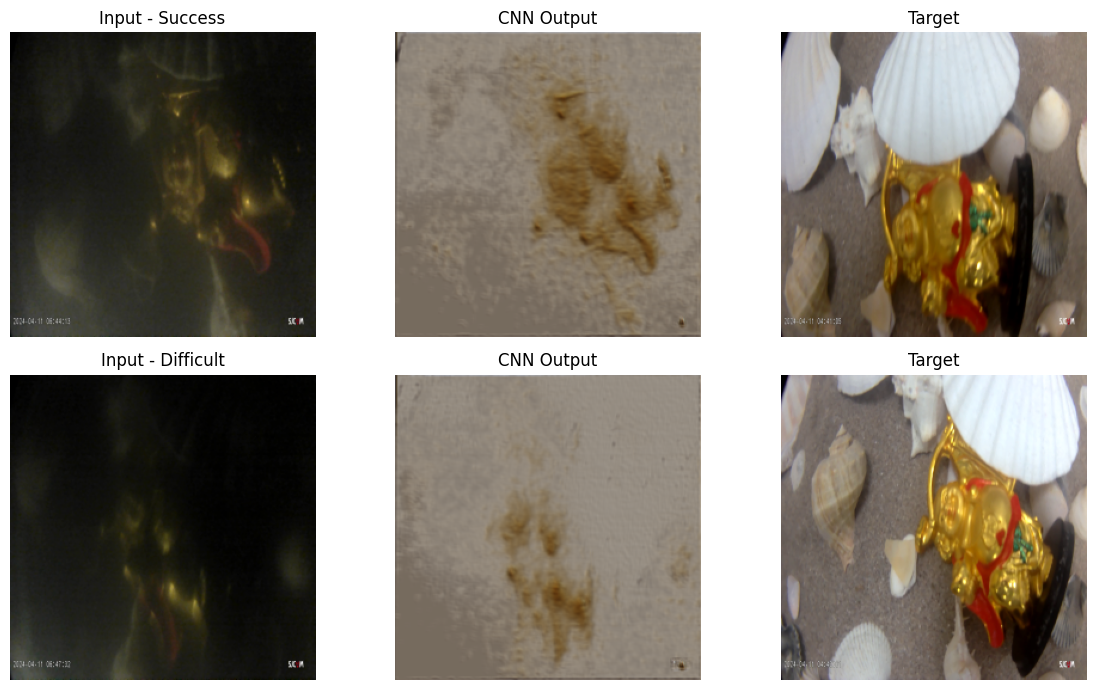

In [ ]:
# Success and Failure Visual Comparison

import matplotlib.pyplot as plt

# Use CNN results from the validation batch
model.eval()

inputs, targets = next(iter(val_loader)) # Get the next batch of input and target images from the validation data loader

inputs = inputs.to(device) # Move input images to the specified device

with torch.no_grad():
    outputs = model(inputs)

inputs = inputs.cpu()
outputs = outputs.cpu()
targets = targets.cpu()

plt.figure(figsize=(12, 7))

i = 0

plt.subplot(2, 3, 1)
plt.imshow(inputs[i].permute(1, 2, 0))
plt.title("Input - Success")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(outputs[i].permute(1, 2, 0).clamp(0,1))
plt.title("CNN Output")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(targets[i].permute(1, 2, 0))
plt.title("Target")
plt.axis("off")

# Difficult / failure example
i = 1

plt.subplot(2, 3, 4)
plt.imshow(inputs[i].permute(1, 2, 0))
plt.title("Input - Difficult")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(outputs[i].permute(1, 2, 0).clamp(0,1))
plt.title("CNN Output")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(targets[i].permute(1, 2, 0))
plt.title("Target")
plt.axis("off")

plt.tight_layout()

plt.show()

# Day 22

In [ ]:
# Final Model / Pipeline Freeze

import torch
import json
import os

# Freeze project configuration
final_config = {
    "Final_Model": "CNN",
    "Classical_Reference": "Refined Gamma",
    "Dataset": "/content/underwater_dataset/underwater_edge_enhancement_dataset",
    "Total_Pairs": 153,
    "Train": 107,
    "Validation": 23,
    "Test": 23,
    "Image_Size": "256x256",
    "Channels": 3,
    "Evaluation_Metrics": [
        "PSNR",
        "SSIM",
        "Edge F1"
    ],
    "CNN_PSNR": 13.5402,
    "CNN_SSIM": 0.4765,
    "CNN_Edge_F1": 0.0451,
    "Gamma_PSNR": 9.4528,
    "Gamma_SSIM": 0.3626,
    "Gamma_Edge_F1": 0.0719
}

# Day 23

In [ ]:
# Final CNN Test Validation

import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import cv2 # Import cv2 for Canny edge detection

model.eval()

psnr_scores = [] # Initialize empty lists to store evaluation scores
ssim_scores = []
edge_scores = []

with torch.no_grad(): # Disable gradient calculation for inference

    for inputs, targets in test_loader: # Iterate over batches from the test data loader, expecting 2 values

        inputs = inputs.to(device) # Move input images to the specified device
        targets = targets.to(device)
        # edge_targets = edge_targets.to(device) # This line caused the error, as test_loader only yields 2 values

        outputs = model(inputs).clamp(0, 1) # Pass inputs through the model and clamp output pixel values to 0-1 range

        for pred, target in zip(outputs, targets): # Iterate through individual predictions and targets in the batch

            pred_np = pred.cpu().numpy().transpose(1, 2, 0) # Convert predicted tensor to NumPy array and reorder dimensions
            target_np = target.cpu().numpy().transpose(1, 2, 0)

            psnr = peak_signal_noise_ratio(target_np, pred_np, data_range=1.0) # Specify data range is 0-1 for normalized image

            ssim = structural_similarity( # Calculate SSIM between target and predicted image
                target_np, pred_np,
                channel_axis=2,
                data_range=1.0
            )

            # Edge F1 using derived edge_target from target_np
            pred_gray = np.mean(pred_np, axis=2) # Convert predicted image to grayscale by averaging color channels
            pred_edge = cv2.Canny(
                (pred_gray * 255).astype(np.uint8),
                100,
                200
            ) > 0

            # Derive edge_target from target_np, similar to how pred_edge is derived
            target_gray = np.mean(target_np, axis=2) # Convert target image to grayscale
            true_edge = cv2.Canny(
                (target_gray * 255).astype(np.uint8),
                100,
                200
            ) > 0

            tp = np.logical_and(pred_edge, true_edge).sum() # Calculate True Positives (common edges)
            fp = np.logical_and(pred_edge, ~true_edge).sum()
            fn = np.logical_and(~pred_edge, true_edge).sum()

            precision = tp / (tp + fp + 1e-8) # Calculate Precision with a small epsilon to avoid division by zero
            recall = tp / (tp + fn + 1e-8)

            edge_f1 = 2 * precision * recall / ( # Calculate Edge F1-score, the harmonic mean of precision and recall
                precision + recall + 1e-8
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)
            edge_scores.append(edge_f1)

final_psnr = np.mean(psnr_scores)
final_ssim = np.mean(ssim_scores)
final_edge = np.mean(edge_scores)

print("Final CNN Test PSNR :", round(final_psnr, 4))
print("Final CNN Test SSIM :", round(final_ssim, 4))
print("Final CNN Test Edge F1 :", round(final_edge, 4))

Final CNN Test PSNR : 13.4626
Final CNN Test SSIM : 0.4594
Final CNN Test Edge F1 : 0.0147


In [ ]:
# CNN Inference Time

import time

model.eval()

start_time = time.time() # Record the start time before inference begins

with torch.no_grad(): # Disable gradient calculation to optimize memory and speed for inference
    for inputs, targets in test_loader:

        inputs = inputs.to(device) # Move input images to the specified device
        outputs = model(inputs)

end_time = time.time() # Record the end time after all inference is complete

total_time = end_time - start_time # Calculate the total time taken for inference
average_time = total_time / len(test_data)

print("Total inference time:", round(total_time, 4), "seconds")
print("Average time per image:", round(average_time, 4), "seconds")

Total inference time: 0.2333 seconds
Average time per image: 0.0101 seconds


In [ ]:
# CNN Model Size

parameters = sum(p.numel() for p in model.parameters() if p.requires_grad) # Calculate the total number of trainable parameters in the model
model_size_mb = parameters * 4 / (1024 ** 2) # Estimate model size in MB

print("Number of parameters:", parameters)
print("Approximate model size:", round(model_size_mb, 4), "MB")

Number of parameters: 11011
Approximate model size: 0.042 MB


In [ ]:
# Final Performance Comparison

import pandas as pd

performance_comparison = pd.DataFrame({
    "Method": [ # Column for method names
        "Refined Gamma",
        "Final CNN"
    ],
    "PSNR": [ # Column for PSNR scores
        9.4528,
        final_psnr
    ],
    "SSIM": [ # Column for SSIM scores
        0.3626,
        final_ssim
    ],
    "Edge F1": [ # Column for Edge F1 scores
        0.0719,
        final_edge
    ],
    "Complexity": [ # Column for complexity assessment
        "Low",
        "Higher"
    ]
})

display(performance_comparison)

,Method,PSNR,SSIM,Edge F1,Complexity
0,Refined Gamma,9.452800,0.362600,0.071900,Low
1,Final CNN,13.462605,0.459406,0.014699,Higher


# Day 25

In [ ]:
# DAY 25: Find worst predictions

model.eval()
results = []

with torch.no_grad():
    for inputs, targets in test_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs).clamp(0, 1)

        for i in range(inputs.size(0)):

            mse = torch.mean(
                (outputs[i] - targets[i]) ** 2
            ).item()

            results.append(
                (mse,
                 inputs[i].cpu(),
                 outputs[i].cpu(),
                 targets[i].cpu())
            )

results.sort(key=lambda x: x[0], reverse=True)

print("Total test images:", len(results))
print("Worst 5 cases selected.")

Total test images: 23
Worst 5 cases selected.


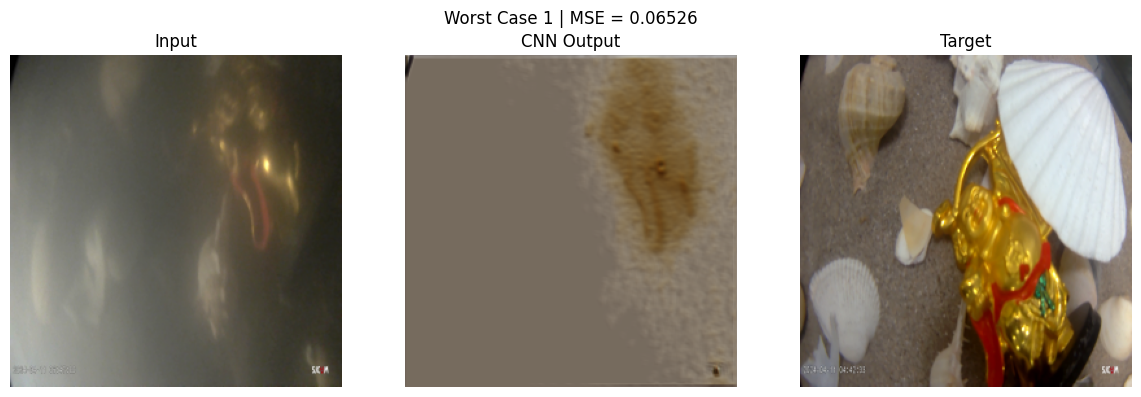

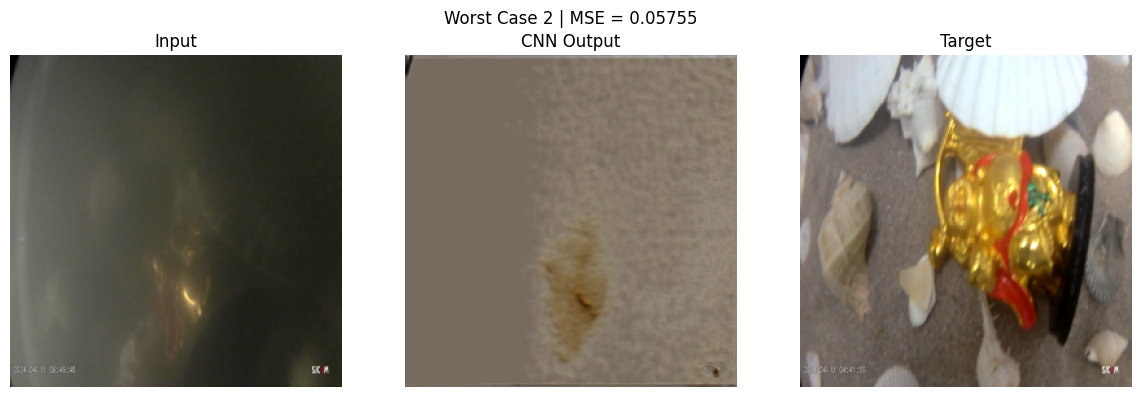

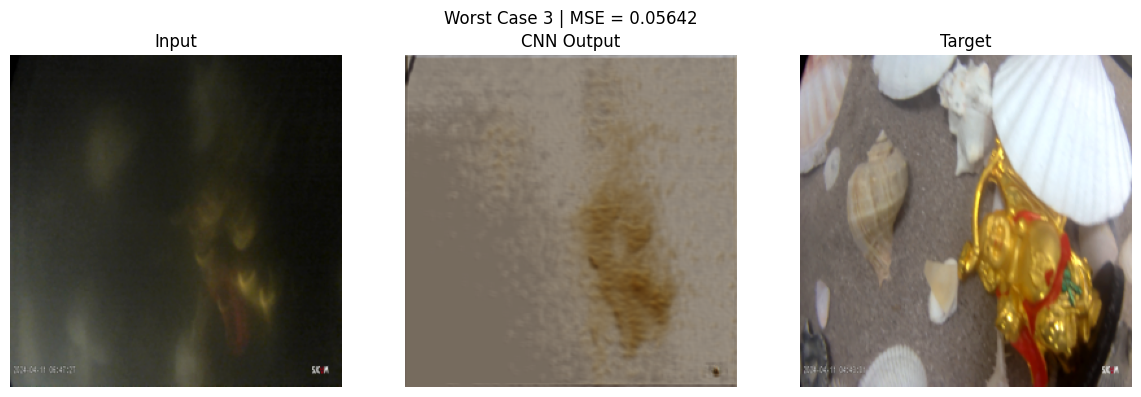

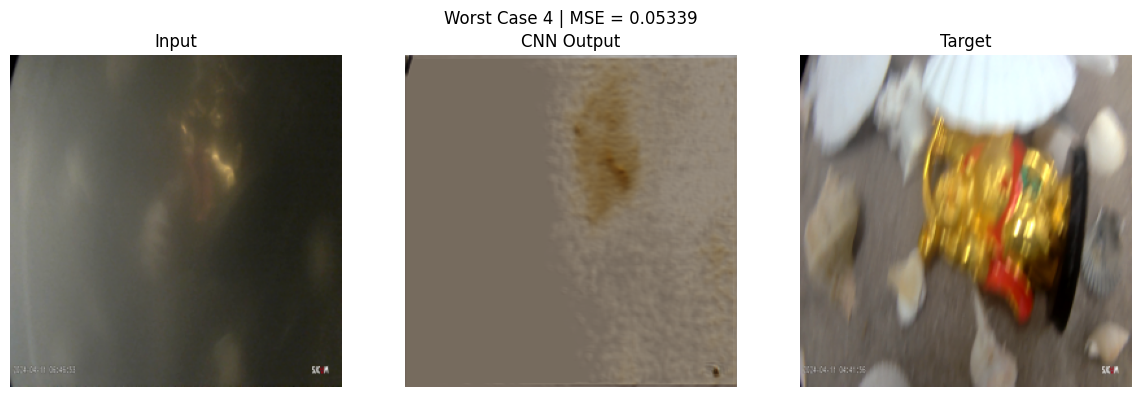

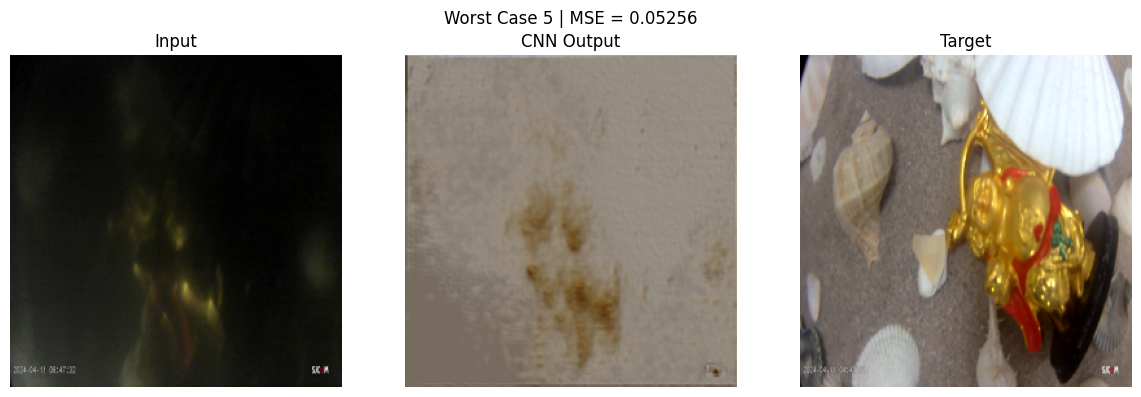

In [ ]:
import matplotlib.pyplot as plt

# Display the 5 worst predictions
for i in range(min(5, len(results))):

    mse, inp, out, tgt = results[i]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(inp.permute(1,2,0).clamp(0,1))
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(out.permute(1,2,0).clamp(0,1))
    plt.title("CNN Output")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(tgt.permute(1,2,0).clamp(0,1))
    plt.title("Target")
    plt.axis("off")

    plt.suptitle(f"Worst Case {i+1} | MSE = {mse:.5f}")
    plt.tight_layout()
    plt.show()

# Day 26

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import cv2
import os


class FusionDataset(Dataset):

    def __init__(self, input_dir, target_dir):

        self.input_dir = input_dir
        self.target_dir = target_dir

        self.files = sorted([
            f for f in os.listdir(input_dir)
            if f.lower().endswith(".png")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        # Original image
        img = np.array(
            Image.open(
                os.path.join(self.input_dir, filename)
            ).convert("RGB")
        )

        # Target image
        target = np.array(
            Image.open(
                os.path.join(self.target_dir, filename)
            ).convert("RGB")
        )

        # Apply all enhancement methods
        he = apply_histogram_equalization(img)

        clahe = apply_clahe(img)

        gamma = apply_gamma(img, gamma=1.9)

        wb = apply_white_balance(img)

        # Convert everything to tensors
        img = torch.tensor(
            img / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        he = torch.tensor(
            he / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        clahe = torch.tensor(
            clahe / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        gamma = torch.tensor(
            gamma / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        wb = torch.tensor(
            wb / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        target = torch.tensor(
            target / 255.0,
            dtype=torch.float32
        ).permute(2, 0, 1)

        return img, he, clahe, gamma, wb, target

In [ ]:
train_dataset = FusionDataset(
    train_input,
    train_target
)

val_dataset = FusionDataset(
    val_input,
    val_target
)

test_dataset = FusionDataset(
    test_input,
    test_target
)


train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 107
Validation: 23
Test: 23


In [ ]:
class FusionCNN(nn.Module):

    def __init__(self):

        super(FusionCNN, self).__init__()

        self.network = nn.Sequential(

            nn.Conv2d(15, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):

        residual = self.network(x)

        # First 3 channels are original input
        original = x[:, 0:3, :, :]

        output = original + residual

        return torch.clamp(output, 0, 1)


model = FusionCNN().to(device)

print(model)

FusionCNN(
  (network): Sequential(
    (0): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [ ]:
def edge_loss(output, target):

    output_gray = output.mean(dim=1, keepdim=True)
    target_gray = target.mean(dim=1, keepdim=True)

    output_x = output_gray[:, :, :, 1:] - output_gray[:, :, :, :-1]
    target_x = target_gray[:, :, :, 1:] - target_gray[:, :, :, :-1]

    output_y = output_gray[:, :, 1:, :] - output_gray[:, :, :-1, :]
    target_y = target_gray[:, :, 1:, :] - target_gray[:, :, :-1, :]

    return (
        F.l1_loss(output_x, target_x) +
        F.l1_loss(output_y, target_y)
    )


def color_loss(output, target):

    output_mean = output.mean(dim=(2, 3))
    target_mean = target.mean(dim=(2, 3))

    return F.l1_loss(output_mean, target_mean)


def enhancement_loss(output, target):

    pixel_loss = F.l1_loss(output, target)

    edge = edge_loss(output, target)

    color = color_loss(output, target)

    return (
        0.7 * pixel_loss +
        0.2 * edge +
        0.1 * color
    )

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0002
)

epochs = 200 # Increased epochs for fine-tuning

train_losses = []
val_losses = []

best_val_loss = float("inf")


for epoch in range(epochs):

    # Training
    model.train()

    total_train_loss = 0

    for original, he, clahe, gamma, wb, target in train_loader:

        original = original.to(device)
        he = he.to(device)
        clahe = clahe.to(device)
        gamma = gamma.to(device)
        wb = wb.to(device)
        target = target.to(device)

        # Combine all five versions
        fusion_input = torch.cat(
            [original, he, clahe, gamma, wb],
            dim=1
        )

        optimizer.zero_grad()

        output = model(fusion_input)

        loss = enhancement_loss(
            output,
            target
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()


    train_loss = (
        total_train_loss /
        len(train_loader)
    )


    # Validation
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for original, he, clahe, gamma, wb, target in val_loader:

            original = original.to(device)
            he = he.to(device)
            clahe = clahe.to(device)
            gamma = gamma.to(device)
            wb = wb.to(device)
            target = target.to(device)

            fusion_input = torch.cat(
                [original, he, clahe, gamma, wb],
                dim=1
            )

            output = model(fusion_input)

            loss = enhancement_loss(
                output,
                target
            )

            total_val_loss += loss.item()


    val_loss = (
        total_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/best_fusion_model.pth"
        )


    print(
        f"Epoch {epoch+1}/{epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )

print(f"\nFinal Train Loss: {train_loss:.4f}")
print(f"Final Val Loss: {val_loss:.4f}")

Epoch 1/200 - Train Loss: 0.2169 - Val Loss: 0.1824
Epoch 2/200 - Train Loss: 0.1495 - Val Loss: 0.1318
Epoch 3/200 - Train Loss: 0.1282 - Val Loss: 0.1242
Epoch 4/200 - Train Loss: 0.1256 - Val Loss: 0.1296
Epoch 5/200 - Train Loss: 0.1247 - Val Loss: 0.1233
Epoch 6/200 - Train Loss: 0.1232 - Val Loss: 0.1231
Epoch 7/200 - Train Loss: 0.1256 - Val Loss: 0.1235
Epoch 8/200 - Train Loss: 0.1230 - Val Loss: 0.1242
Epoch 9/200 - Train Loss: 0.1231 - Val Loss: 0.1238
Epoch 10/200 - Train Loss: 0.1227 - Val Loss: 0.1228
Epoch 11/200 - Train Loss: 0.1217 - Val Loss: 0.1246
Epoch 12/200 - Train Loss: 0.1219 - Val Loss: 0.1245
Epoch 13/200 - Train Loss: 0.1219 - Val Loss: 0.1221
Epoch 14/200 - Train Loss: 0.1217 - Val Loss: 0.1258
Epoch 15/200 - Train Loss: 0.1218 - Val Loss: 0.1218
Epoch 16/200 - Train Loss: 0.1210 - Val Loss: 0.1229
Epoch 17/200 - Train Loss: 0.1209 - Val Loss: 0.1237
Epoch 18/200 - Train Loss: 0.1207 - Val Loss: 0.1214
Epoch 19/200 - Train Loss: 0.1206 - Val Loss: 0.1225
Ep

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/best_fusion_model.pth",
        map_location=device
    )
)

model.eval()

print("Best fusion model loaded.")

Best fusion model loaded.


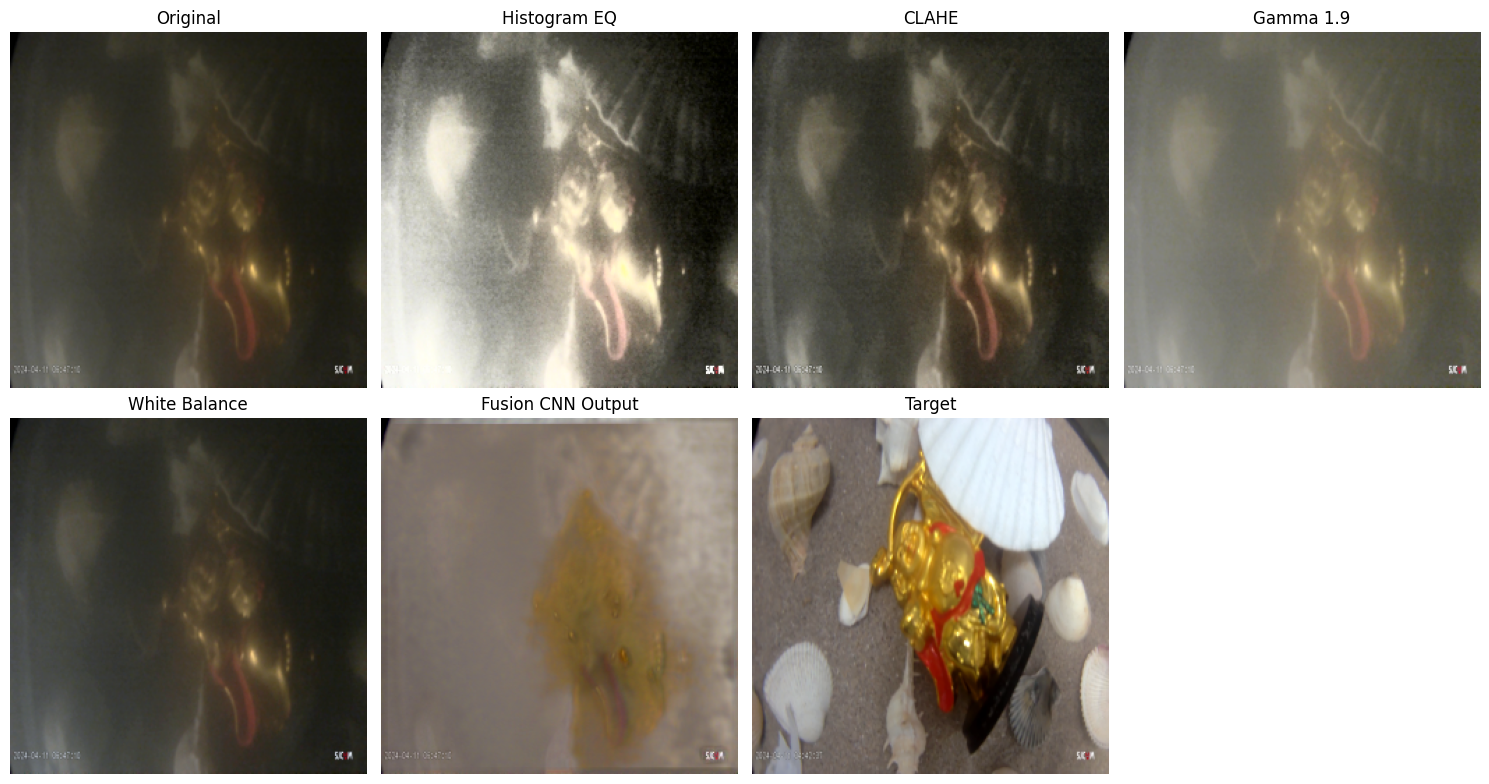

In [ ]:
import matplotlib.pyplot as plt

model.eval()

original, he, clahe, gamma, wb, target = next(
    iter(test_loader)
)

original = original.to(device)
he = he.to(device)
clahe = clahe.to(device)
gamma = gamma.to(device)
wb = wb.to(device)
target = target.to(device)


fusion_input = torch.cat(
    [original, he, clahe, gamma, wb],
    dim=1
)


with torch.no_grad():

    output = model(fusion_input)


plt.figure(figsize=(15, 8))


plt.subplot(2, 4, 1)
plt.imshow(original[0].cpu().permute(1,2,0))
plt.title("Original")
plt.axis("off")


plt.subplot(2, 4, 2)
plt.imshow(he[0].cpu().permute(1,2,0))
plt.title("Histogram EQ")
plt.axis("off")


plt.subplot(2, 4, 3)
plt.imshow(clahe[0].cpu().permute(1,2,0))
plt.title("CLAHE")
plt.axis("off")


plt.subplot(2, 4, 4)
plt.imshow(gamma[0].cpu().permute(1,2,0))
plt.title("Gamma 1.9")
plt.axis("off")


plt.subplot(2, 4, 5)
plt.imshow(wb[0].cpu().permute(1,2,0))
plt.title("White Balance")
plt.axis("off")


plt.subplot(2, 4, 6)
plt.imshow(output[0].cpu().permute(1,2,0))
plt.title("Fusion CNN Output")
plt.axis("off")


plt.subplot(2, 4, 7)
plt.imshow(target[0].cpu().permute(1,2,0))
plt.title("Target")
plt.axis("off")


plt.tight_layout()
plt.show()

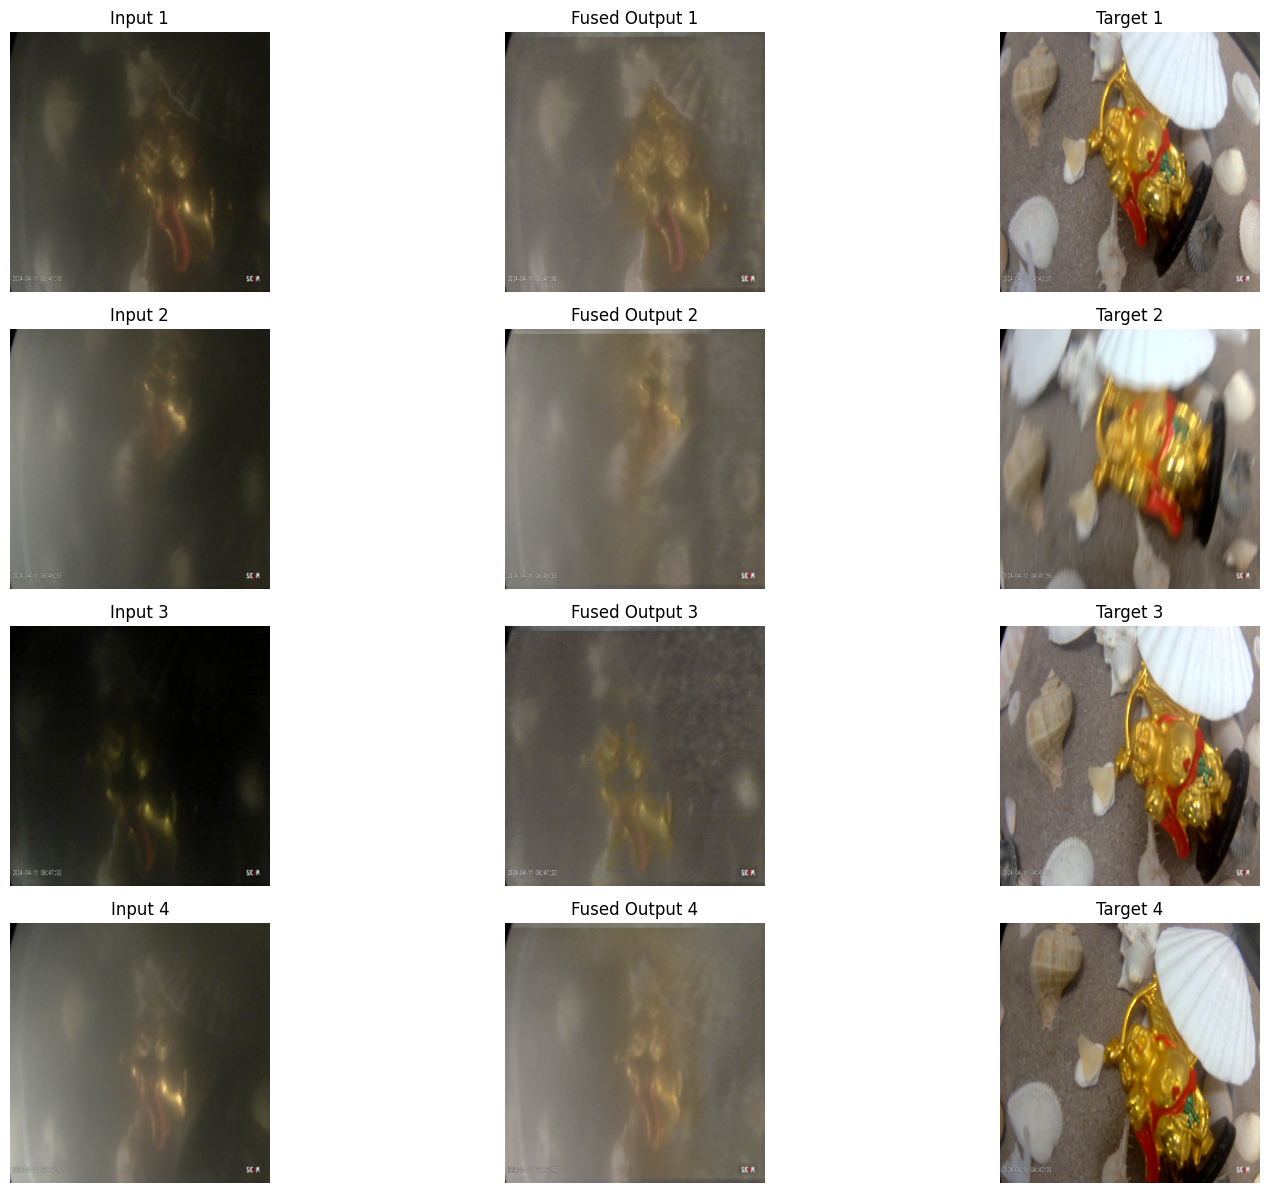

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

model.eval()

# Get a batch of test images
# The FusionDataset returns original, he, clahe, gamma, wb, target
original_batch, he_batch, clahe_batch, gamma_batch, wb_batch, target_batch = next(iter(test_loader))

num_images_to_display = 5 # Display 5 images

plt.figure(figsize=(15, num_images_to_display * 3))

for i in range(min(num_images_to_display, len(original_batch))):

    # Convert tensors back to numpy for classical methods and visualization
    input_img_np = (original_batch[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    target_img_np = (target_batch[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    he_img = apply_histogram_equalization(input_img_np)
    clahe_img = apply_clahe(input_img_np)
    gamma_img = apply_gamma(input_img_np, gamma=1.9)
    wb_img = apply_white_balance(input_img_np)

    # Convert all processed images to tensors and unsqueeze to add batch dimension
    original_tensor_single = original_batch[i].unsqueeze(0).to(device)
    he_tensor_single = (torch.from_numpy(he_img.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device))
    clahe_tensor_single = (torch.from_numpy(clahe_img.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device))
    gamma_tensor_single = (torch.from_numpy(gamma_img.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device))
    wb_tensor_single = (torch.from_numpy(wb_img.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device))

    # Concatenate all tensors to form the 15-channel input for FusionCNN
    fusion_cnn_input = torch.cat(
        [original_tensor_single, he_tensor_single, clahe_tensor_single, gamma_tensor_single, wb_tensor_single],
        dim=1
    )

    with torch.no_grad():
        cnn_output_single = model(fusion_cnn_input).clamp(0, 1)

    cnn_img_np = (
        cnn_output_single[0]
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    he_img_float = he_img.astype(np.float32) / 255.0
    clahe_img_float = clahe_img.astype(np.float32) / 255.0
    gamma_img_float = gamma_img.astype(np.float32) / 255.0
    wb_img_float = wb_img.astype(np.float32) / 255.0

    final_output = (
        0.05 * he_img_float +
        0.20 * clahe_img_float +
        0.20 * gamma_img_float +
        0.10 * wb_img_float +
        0.45 * cnn_img_np
    )

    # Keep pixels in valid range
    final_output = np.clip(final_output, 0, 1)

    plt.subplot(num_images_to_display, 3, i * 3 + 1)
    plt.imshow(input_img_np)
    plt.title(f"Input {i+1}")
    plt.axis("off")

    plt.subplot(num_images_to_display, 3, i * 3 + 2)
    plt.imshow(final_output)
    plt.title(f"Fused Output {i+1}")
    plt.axis("off")

    plt.subplot(num_images_to_display, 3, i * 3 + 3)
    plt.imshow(target_img_np)
    plt.title(f"Target {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()